In this notebook, I demonstrate my ability to code using PyTorch by building and training a Convolutional Neural Network (CNN) on the CIFAR-10 dataset. The goal of this project is to classify images into one of 10 categories, including animals, vehicles, and more.

The primary objective is to showcase essential PyTorch skills, particularly in working with image classification tasks. This includes building, training, and evaluating a CNN model, which is a common architecture for handling image-based data. Additionally, the project covers crucial steps in the PyTorch workflow, such as data loading, preprocessing, model construction, training loops, and performance evaluation.

This notebook also emphasizes best practices like device agnostic code for compatibility across different hardware (CPU vs GPU), as well as techniques for evaluating model performance using metrics like accuracy and confusion matrices. By adapting the workflow to a well-known dataset, I am able to apply theoretical concepts in a practical scenario, demonstrating how PyTorch can be used effectively for image classification tasks.

Key enhancements include:

Data preprocessing with proper normalization and shuffling.
Building a multi-layer CNN architecture for image classification. Implementing training and testing loops with evaluation metrics.

This notebook serves as a practical introduction to the key steps in the PyTorch deep learning pipeline and highlights its application to real-world machine learning problems like image classification. The workflow in this notebook is adapted from a PyTorch tutorial on computer vision workflows (https://www.learnpytorch.io/03_pytorch_computer_vision).


In [ ]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121


In [ ]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.3/927.3 kB 12.7 MB/s eta 0:00:00


# Data Pre-Processing


Data is CIFAR 10. A classic dataset containing 60,000 color images (32x32 pixels). CIFAR-10 includes 10 classes, and CIFAR-100 has 100 fine-grained classes.


In [ ]:
''' pre-processing choices:
Transforms:
Added data augmentation (RandomHorizontalFlip and RandomCrop) to the training data. These augmentations improve generalization by making the model robust to variations.
Used Normalize for standardizing the RGB pixel values of the images to a mean of 0.5 and a standard deviation of 0.5 per channel.
Normalization for Testing Data: The test dataset does not include augmentations, but it is normalized in the same way as the training dataset to ensure consistency.
'''


# Setup training data
train_data = datasets.CIFAR10(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=torchvision.transforms.Compose([
        torchvision.transforms.RandomHorizontalFlip(),  # Data augmentation: randomly flip images
        torchvision.transforms.RandomCrop(32, padding=4),  # Data augmentation: random crop with padding
        ToTensor(),  # Convert PIL images to Torch tensors
        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize RGB channels
    ])
)

# Setup testing data
test_data = datasets.CIFAR10(
    root="data",
    train=False, # get test data
    download=True,
    transform=torchvision.transforms.Compose([
        ToTensor(),  # Convert PIL images to Torch tensors
        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize RGB channels
    ])
)

100%|██████████| 170M/170M [00:11<00:00, 14.4MB/s]


Extracting data/cifar-10-python.tar.gz to data
Files already downloaded and verified


In [ ]:
# Some data sanity checks

#See first training sample
image, label = train_data[0]
#print(image, label)
print(train_data[0])

'''The tensor represents the normalized image data (values between -1 and 1 due to the Normalize transform).
6 is the label, which corresponds to the 6th class in the class_names list ('frog' in this case).'''

# See the shape of the image
print(image.shape)
# so input = [color_channels=3 (RBG), height=32, width=32] (= CHW)

# Sample size
print(len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets))

# See classes
class_names = train_data.classes
print(class_names)
# so while input is 3 (CHW), output will be 10 prediction probabilities for each class.
# (e.g. 0.80 for T-shirt/top, 0.1 for shirt 0.1 for dress and 0's for other clothing types)

(tensor([[[-1.0000, -1.0000, -0.7412,  ...,  0.0588,  0.0196, -0.0196],
         [-1.0000, -1.0000, -0.6078,  ..., -0.0667, -0.1922, -0.3176],
         [-1.0000, -1.0000, -0.4431,  ..., -0.1608, -0.3098, -0.4745],
         ...,
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],

        [[-1.0000, -1.0000, -0.8039,  ..., -0.2706, -0.2941, -0.3176],
         [-1.0000, -1.0000, -0.7490,  ..., -0.3804, -0.4745, -0.5529],
         [-1.0000, -1.0000, -0.6235,  ..., -0.4667, -0.5765, -0.6941],
         ...,
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],

        [[-1.0000, -1.0000, -0.8667,  ..., -0.6000, -0.6078, -0.6078],
         [-1.0000, -1.0000, -0.8353,  ..., -

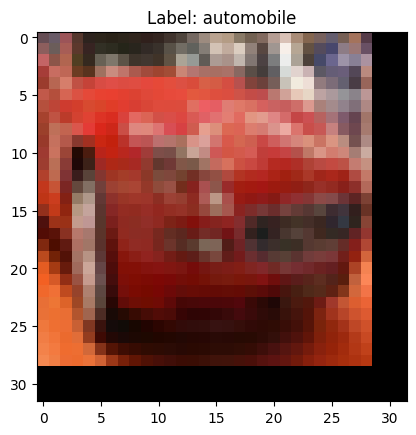

In [ ]:
# data visualisation
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize and display an image
def show_image(img, label):
    img = img / 2 + 0.5  # Unnormalize (reverse the normalization step)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Convert CHW to HWC for plotting
    plt.title(f"Label: {class_names[label]}")
    plt.show()

# Visualize the first training image
show_image(image, label)


In [ ]:
#check label distribution

from collections import Counter

train_labels = [label for _, label in train_data]
label_distribution = Counter(train_labels)
print(label_distribution)


Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


In [ ]:
# set dataloader to create batches for computational efficiency
''' PyTorch documentation : The Dataset retrieves our dataset’s features and labels one sample at a time.
While training a model, we typically want to pass samples in “minibatches”,
reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.
DataLoader is an iterable that abstracts this complexity for us in an easy API.
https://pytorch.org/tutorials/beginner/basics/data_tutorial.html'''

from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # sample size per batch
    shuffle=True # shuffle data every epoch
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # not needed for testing data
)

# See what the dataloader has resulted in
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7c8fbe2c4af0>, <torch.utils.data.dataloader.DataLoader object at 0x7c8fbe2c45e0>)
Length of train dataloader: 1563 batches of 32
Length of test dataloader: 313 batches of 32


In [ ]:
# Sanity check to see what's inside the training dataloader
# Fetch one batch of data - shape should be unchanged
train_features_batch, train_labels_batch = next(iter(train_dataloader))

# Print batch details
print(f"Feature batch shape: {train_features_batch.shape}")  # Expected: [BATCH_SIZE, 3, 32, 32]
print(f"Label batch shape: {train_labels_batch.shape}")  # Expected: [BATCH_SIZE]
print(f"Labels: {train_labels_batch}")  # Class indices for the batch



Feature batch shape: torch.Size([32, 3, 32, 32])
Label batch shape: torch.Size([32])
Labels: tensor([3, 4, 9, 1, 4, 3, 5, 3, 3, 4, 3, 7, 1, 7, 9, 9, 2, 2, 7, 5, 2, 9, 3, 4,
        8, 6, 3, 8, 7, 7, 3, 1])


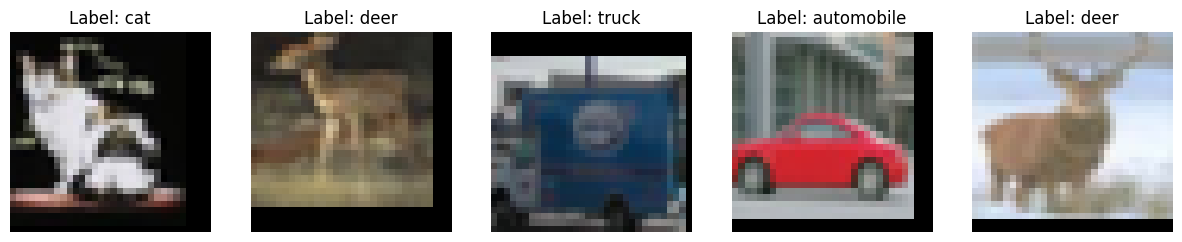

In [ ]:

# Unnormalize and visualize some images in the batch
def unnormalize(img):
    img = img / 2 + 0.5  # Reverse normalization
    return img

# Plot the first few images and their labels
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    img = unnormalize(train_features_batch[i])  # Unnormalize the image
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))  # CHW to HWC for display
    ax.set_title(f"Label: {class_names[train_labels_batch[i]]}")
    ax.axis("off")

plt.show()


## Improved model version: CNN - Convolutional Neural Network


In [ ]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# Create a convolutional neural network
class CIFAR10ModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # size of square that's going over the image
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*8*8, #CIFAR-10 images are (32x32). After two blocks of convolution and max pooling, the flattened size will be hidden_units * 8 * 8
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model_2 = CIFAR10ModelV2(
    input_shape=3, #3 channels for RGB
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=640, out_features=10, bias=True)
  )
)

In [ ]:
from torchsummary import summary

summary(model_2, (3, 32, 32))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 32, 32]             280
              ReLU-2           [-1, 10, 32, 32]               0
            Conv2d-3           [-1, 10, 32, 32]             910
              ReLU-4           [-1, 10, 32, 32]               0
         MaxPool2d-5           [-1, 10, 16, 16]               0
            Conv2d-6           [-1, 10, 16, 16]             910
              ReLU-7           [-1, 10, 16, 16]               0
            Conv2d-8           [-1, 10, 16, 16]             910
              ReLU-9           [-1, 10, 16, 16]               0
        MaxPool2d-10             [-1, 10, 8, 8]               0
          Flatten-11                  [-1, 640]               0
           Linear-12                   [-1, 10]           6,410
Total params: 9,420
Trainable params: 9,420
Non-trainable params: 0
-----------------------------------

In [ ]:
# Setup loss function (Cross Entropy Loss for multi-class classification)
loss_fn = nn.CrossEntropyLoss()

# Setup optimizer (Adam with default learning rate of 0.001)
optimizer = torch.optim.Adam(params=model_2.parameters(),
                             lr=0.001)  # You can experiment with the learning rate if needed

# Check if everything is set up correctly
print(f"Loss Function: {loss_fn}")
print(f"Optimizer: {optimizer}")


Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
import torchmetrics

# Initialize accuracy metric
accuracy_metric = torchmetrics.Accuracy(task='multiclass', num_classes=len(class_names)).to(device)



In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               metric: torchmetrics.Metric,
               device: torch.device = device):
    model.to(device)
    model.train()  # Set model to training mode
    train_loss, train_acc = 0.0, 0.0

    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Update accuracy metric
        metric.update(y_pred, y)  # Update accuracy metric with predictions and true labels

        # 4. Optimizer zero grad
        optimizer.zero_grad()

        # 5. Loss backward
        loss.backward()

        # 6. Optimizer step
        optimizer.step()

    # Get final accuracy
    train_acc = metric.compute()

    # Calculate loss and accuracy per epoch and print out
    train_loss /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

    # Reset the metric for next epoch
    metric.reset()

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              metric: torchmetrics.Metric,
              device: torch.device = device):
    model.to(device)
    model.eval()  # Set model to evaluation mode
    test_loss, test_acc = 0.0, 0.0

    with torch.no_grad():  # Disable gradient calculation during inference
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss
            loss = loss_fn(test_pred, y)
            test_loss += loss.item()

            # 3. Update accuracy metric
            metric.update(test_pred, y)

        # Get final accuracy
        test_acc = metric.compute()

    # Calculate loss and accuracy per epoch and print out
    test_loss /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

    # Reset the metric for next epoch
    metric.reset()


In [ ]:
torch.manual_seed(42)


# Train and test model
# Setup number of epochs
NUM_EPOCHS = 10  # Adjust as needed

# Loop through the epochs
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    # Train the model
    print("Training...")
    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               metric=accuracy_metric,
               device=device)

    # Test the model
    print("Testing...")
    test_step(data_loader=test_dataloader,
              model=model_2,
              loss_fn=loss_fn,
              metric=accuracy_metric,
              device=device)




Epoch 1/10
Training...
Train loss: 1.77949 | Train accuracy: 0.35%
Testing...
Test loss: 1.54020 | Test accuracy: 0.44%

Epoch 2/10
Training...
Train loss: 1.51834 | Train accuracy: 0.45%
Testing...
Test loss: 1.32768 | Test accuracy: 0.52%

Epoch 3/10
Training...
Train loss: 1.38959 | Train accuracy: 0.50%
Testing...
Test loss: 1.22481 | Test accuracy: 0.56%

Epoch 4/10
Training...
Train loss: 1.31095 | Train accuracy: 0.53%
Testing...
Test loss: 1.16487 | Test accuracy: 0.59%

Epoch 5/10
Training...
Train loss: 1.24652 | Train accuracy: 0.55%
Testing...
Test loss: 1.10729 | Test accuracy: 0.61%

Epoch 6/10
Training...
Train loss: 1.19668 | Train accuracy: 0.57%
Testing...
Test loss: 1.09932 | Test accuracy: 0.60%

Epoch 7/10
Training...
Train loss: 1.17383 | Train accuracy: 0.58%
Testing...
Test loss: 1.07230 | Test accuracy: 0.62%

Epoch 8/10
Training...
Train loss: 1.14698 | Train accuracy: 0.59%
Testing...
Test loss: 1.03908 | Test accuracy: 0.63%

Epoch 9/10
Training...
Train los

### Compare model results


### Use model to make predictions and evaluate predictiona

In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [ ]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=5):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([3, 32, 32])
Test sample label: 9 (truck)


In [ ]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=model_2,
                             data=test_samples)

# View first two prediction probabilities list
pred_probs[:2]

tensor([[9.7681e-03, 4.7323e-02, 2.5339e-05, 1.3714e-04, 8.8008e-05, 1.6590e-05,
         8.2238e-05, 7.7967e-04, 5.9655e-03, 9.3581e-01],
        [1.5487e-03, 7.6927e-07, 6.3311e-01, 1.2513e-01, 4.2589e-02, 1.7341e-01,
         6.9496e-03, 1.6964e-02, 5.4070e-05, 2.4842e-04]])

In [ ]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
#print(pred_classes)

# Sanity check that the predictions are in the same form as our test labels
test_labels, pred_classes

([9, 2, 1, 3, 7], tensor([9, 2, 1, 7, 5]))

In [ ]:
# extract wrong predictions
for i, sample in enumerate(test_samples):
  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Check for equality and change title colour accordingly
  if pred_label != truth_label:
      print("incorrect prediction")
      print(f"pred_label = {class_names[pred_classes[i]]}, truth_label = {class_names[test_labels[i]]}")


incorrect prediction
pred_label = horse, truth_label = cat
incorrect prediction
pred_label = dog, truth_label = horse


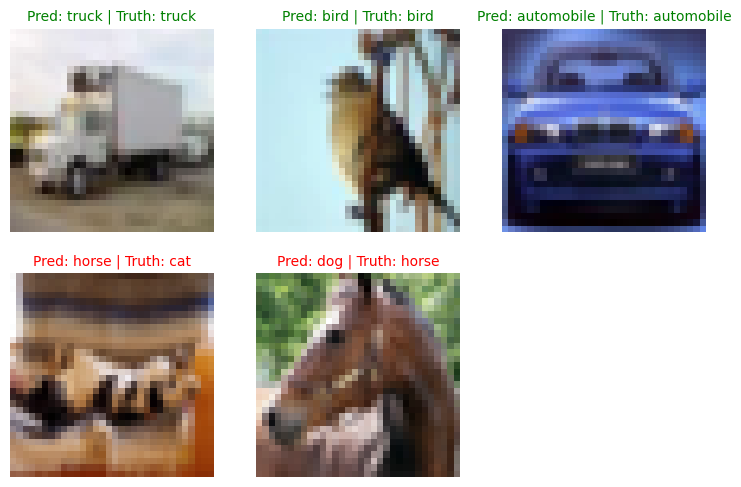

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    # Create a subplot
    plt.subplot(nrows, ncols, i+1)

    # Normalize image to [0, 1] if the pixel values are in range [-1, 1]
    sample = (sample - sample.min()) / (sample.max() - sample.min())

    # Plot the target image (permute to convert the shape from [3, 32, 32] to [32, 32, 3])
    plt.imshow(sample.permute(1, 2, 0))  # This corrects the shape for plotting

    # Find the prediction label (in text form, e.g. "Sandal")
    pred_label = class_names[pred_classes[i]]

    # Get the truth label (in text form, e.g. "T-shirt")
    truth_label = class_names[test_labels[i]]

    # Create the title text of the plot
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    # Check for equality and change title colour accordingly
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")  # green text if correct
    else:
        plt.title(title_text, fontsize=10, c="r")  # red text if wrong
    plt.axis(False)  # Hide the axis


In [ ]:
import torch
from torchmetrics import ConfusionMatrix
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
import numpy as np
from tqdm.auto import tqdm

# Step 1: Make predictions with trained model
y_preds = []
y_true = []

model_2.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        # Send data and targets to target device
        X, y = X.to(device), y.to(device)

        # Do the forward pass
        y_logit = model_2(X)

        # Turn predictions from logits -> prediction probabilities -> prediction labels
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)

        # Append the predictions and true labels to lists
        y_preds.append(y_pred.cpu())
        y_true.append(y.cpu())

# Concatenate lists into tensors
y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)



Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

In [ ]:
# Step 2: Create a confusion matrix using torchmetrics
conf_matrix = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
conf_matrix.update(y_pred_tensor, y_true_tensor)
# Step 3: Convert the confusion matrix tensor to a NumPy array
conf_matrix_np = conf_matrix.compute().numpy()


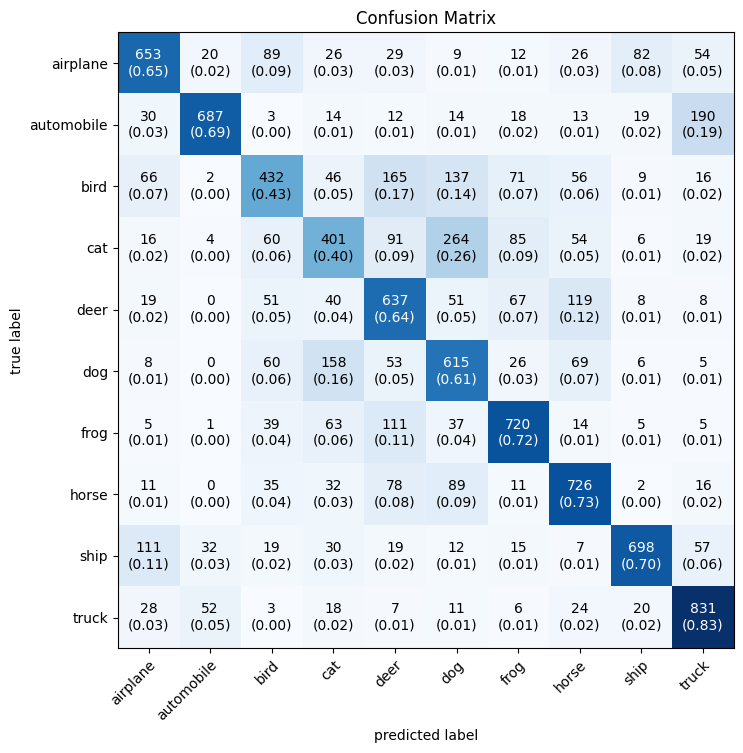

In [ ]:

# Step 4: Plotting the confusion matrix using mlxtend
fig, ax = plot_confusion_matrix(conf_mat=conf_matrix_np,
                      class_names=class_names,
                      figsize=(10, 8),
                      cmap='Blues',
                      show_normed=True)
plt.title("Confusion Matrix")
plt.show()